In [1]:
%load_ext jupyter_black

In [2]:
import lamindb as ln
from napari_spatialdata import Interactive  # noqa: F401
import spatialdata as sd
import spatialdata_plot
import easy_vitessce
from spatialdata._io.format import RasterFormatV02, SpatialDataContainerFormatV01

→ connected lamindb: scverse/spatialdata-db


/Users/macbook/embl/projects/basel/3d-spatial-workshop-2025/.venv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


Note: we are using an unreleased branch of `spatialdata` than relaxes the constraint around `dask`: https://github.com/scverse/spatialdata/pull/1006. Some unstable behavior may occur for points.

## Loading the data from `spatialdata-db`

We will download a Xenium dataset from the SpatialData-DB. For a detailed introduction on SpatialData-DB, please refert to this tutorial: https://github.com/scverse/202503_hackathon_owkin/blob/main/data/intro.ipynb.

SpatialData-DB is under active development, you may encounter breaking changes. Lead authors: Lea Zimmermann (co-lead), Tim Treis (co-lead scverse), Lukas Heumos (scverse), Wouter Vierdag (scverse), Luca Marconato (scverse).

In [3]:
# we will download the dataset "Xenium FFPE Healthy Human Breast", provided from 10x Genomics https://www.10xgenomics.com/datasets/ffpe-human-breast-with-custom-add-on-panel-1-standard
#
# spatialdata-db link:
# https://lamin.ai/scverse/spatialdata-db/artifacts?filter[and][0][or][0][is_latest][eq]=true&filter[and][1][or][0][branch.name][eq]=main&filter[and][2][or][0][schema.name][eq]=Xenium
artifact = ln.Artifact.get("Uj7J4jjgzHw0lcm80001")
gb = artifact.size / 1_000_000_000
print(f"{gb:.2f} GB")

7.23 GB


In [4]:
print(artifact.description)

Xenium FFPE Healthy Human Breast (Tissue sample 2, Custom Panel)


In [5]:
artifact.cache()
f = artifact._cache_path

! run input wasn't tracked, call `ln.track()` and re-run


In [6]:
sdata = sd.read_zarr(str(f))
print(sdata)

/tmp/ipykernel_45811/2598112575.py:1: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(str(f))
/Users/macbook/embl/projects/basel/3d-spatial-workshop-2025/.venv/lib/python3.12/site-packages/zarr/core/group.py:3530: ZarrUserWarning: Object at .DS_Store is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


SpatialData object, with associated Zarr store: /Users/macbook/Library/Caches/lamindb/scverse-spatial-eu-central-1/10pf0.zarr
├── Images
│     ├── 'morphology_focus': DataTree[cyx] (1, 41411, 45749), (1, 20705, 22874), (1, 10352, 11437), (1, 5176, 5718), (1, 2588, 2859)
│     ├── 'morphology_focus_scale3': DataArray[cyx] (1, 5176, 5718)
│     └── 'morphology_mip': DataTree[cyx] (1, 41411, 45749), (1, 20705, 22874), (1, 10352, 11437), (1, 5176, 5718), (1, 2588, 2859)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (41411, 45749), (20705, 22874), (10352, 11437), (5176, 5718), (2588, 2859)
│     └── 'nucleus_labels': DataTree[yx] (41411, 45749), (20705, 22874), (10352, 11437), (5176, 5718), (2588, 2859)
├── Points
│     └── 'transcripts': DataFrame with shape: (<dask_expr.expr.Scalar: expr=ReadParquetFSSpec(1af4f57).size() // 8, dtype=int64>, 8) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (365604, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (3

/Users/macbook/embl/projects/basel/3d-spatial-workshop-2025/.venv/lib/python3.12/site-packages/zarr/core/group.py:3530: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/Users/macbook/embl/projects/basel/3d-spatial-workshop-2025/.venv/lib/python3.12/site-packages/zarr/core/group.py:3530: ZarrUserWarning: Object at .DS_Store is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


## Plotting with `easy-vitessce`

[Pre-print](https://arxiv.org/abs/2510.19532), [repo](https://arxiv.org/abs/2510.19532). Easy-vitessce has been developed by Selena Luo and Mark Keller.

In [7]:
# there is a problem in rending the multiscale image in easy-vitessce
sdata.pl.render_shapes("cell_circles", color="ABCC11").pl.show()

In [17]:
easy_vitessce.configure_plots(disable_plots=["spatialdata-plot"])

Deactivated Vitessce spatialdata-plot


INFO     Rasterizing image for faster rendering.                                                                   


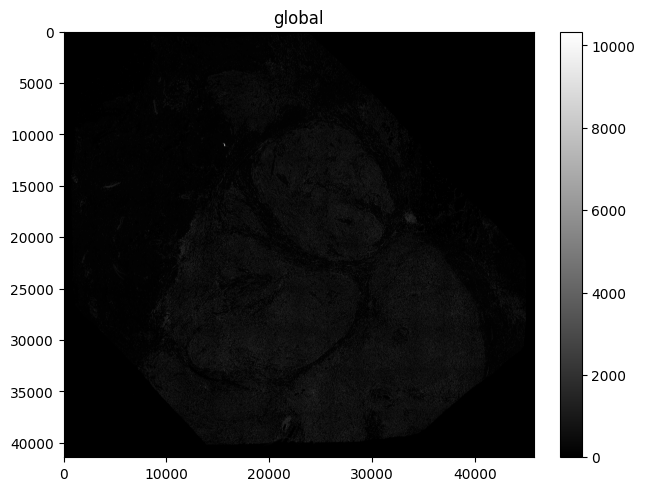

In [9]:
sdata.pl.render_images("morphology_mip", cmap="gray").pl.show()

In [10]:
import numpy as np

dt = sdata["morphology_mip"].map_over_datasets(lambda ds: ds.map(np.arcsinh))

INFO     Rasterizing image for faster rendering.                                                                   


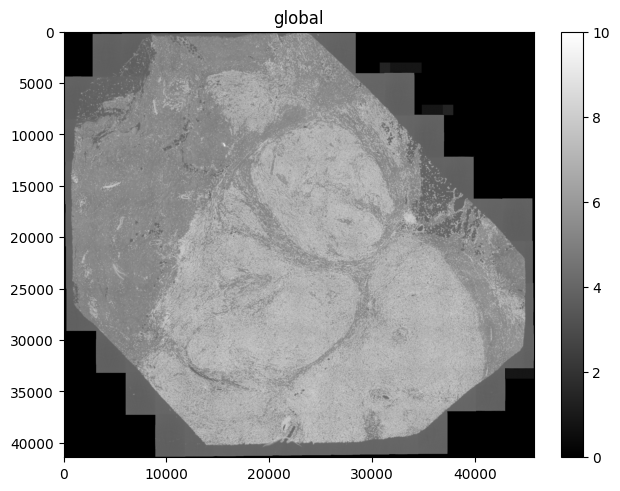

In [11]:
sdata["morphology_mip_asinh"] = sd.models.Image2DModel.parse(dt["scale2"]["image"])
sdata.pl.render_images("morphology_mip_asinh", cmap="gray").pl.show()

In [24]:
small_sdata = sd.bounding_box_query(
    sdata,
    min_coordinate=[5000, 5000],
    max_coordinate=[14000, 14000],
    axes=("x", "y"),
    target_coordinate_system="global",
)

/Users/macbook/.local/share/uv/python/cpython-3.12.8-macos-aarch64-none/lib/python3.12/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


INFO     Rasterizing image for faster rendering.                                                                   
INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' do disable this    
         behaviour.                                                                                                


/Users/macbook/.local/share/uv/python/cpython-3.12.8-macos-aarch64-none/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/macbook/embl/projects/basel/3d-spatial-workshop-2025/.venv/lib/python3.12/site-packages/dask/dataframe/dask_expr/_collection.py:1435: UserWarning: Dask currently has limited support for converting pandas extension dtypes to arrays. Converting string to object dtype.
  warnings.warn(
/Users/macbook/embl/projects/basel/3d-spatial-workshop-2025/.venv/lib/python3.12/site-packages/dask/dataframe/dask_expr/_collection.py:1435: UserWarning: Dask currently has limited support for converting pandas extension dtypes to arrays. Converting string to object dtype.
  warnings.warn(


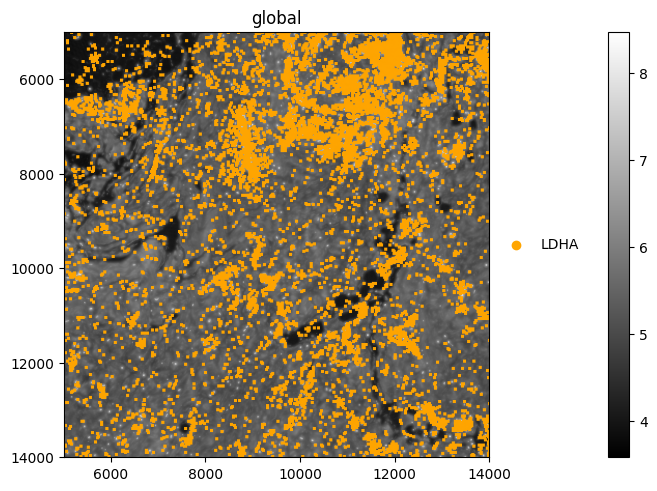

In [25]:
(
    small_sdata.pl.render_images("morphology_mip_asinh", cmap="gray")
    .pl.render_points(
        "transcripts", color="feature_name", groups="LDHA", palette="orange"
    )
    .pl.show()
)

In [12]:
easy_vitessce.configure_plots(enable_plots=["spatialdata-plot"])